## 특성 공학

- 특성 공학(feature engineering)은 기존의 특성을 사용해 새로운 특성을 뽑아내는 작업입니다.

- 예제에서는 농어의 길이 뿐만 아니라 농어의 높이와 두께도 함께 사용하고, 3개의 특성을 각각 제곱하여 추가합니다.

- 각 특성을 서로 곱해서 또 다른 특성을 생성합니다.  
    예) '농어 길이 x 농어 높이'

- 여러 개의 특성을 사용한 선형회귀를 다중회귀(Multiple Regression)라고 합니다.

## 데이터 준비

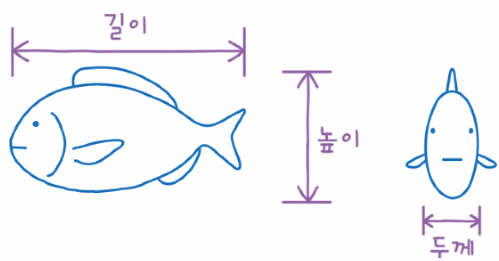

In [1]:
%pip install pandas

  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   --------------- ------------------------ 3.7/9.7 MB 19.8 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.7 MB 26.3 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 25.3 MB/s  0:00:00
Using cached tzdata-2025.3-py2.py3-none-any.whl (348 kB)

   ---------------------------------------- 0/2 [tzdata]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   ----

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('data/perch_full.csv')

print(df.columns, end='\n\n')

df.head()

Index(['length', ' height', ' width'], dtype='str')



,length,height,width
0,8.4,2.11,1.41
1,13.7,3.53,2.00
2,15.0,3.82,2.43
3,16.2,4.59,2.63
4,17.4,4.59,2.94


In [4]:
perch_full = df.to_numpy()

print(perch_full)

[[ 8.4   2.11  1.41]
 [13.7   3.53  2.  ]
 [15.    3.82  2.43]
 [16.2   4.59  2.63]
 [17.4   4.59  2.94]
 [18.    5.22  3.32]
 [18.7   5.2   3.12]
 [19.    5.64  3.05]
 [19.6   5.14  3.04]
 [20.    5.08  2.77]
 [21.    5.69  3.56]
 [21.    5.92  3.31]
 [21.    5.69  3.67]
 [21.3   6.38  3.53]
 [22.    6.11  3.41]
 [22.    5.64  3.52]
 [22.    6.11  3.52]
 [22.    5.88  3.52]
 [22.    5.52  4.  ]
 [22.5   5.86  3.62]
 [22.5   6.79  3.62]
 [22.7   5.95  3.63]
 [23.    5.22  3.63]
 [23.5   6.28  3.72]
 [24.    7.29  3.72]
 [24.    6.38  3.82]
 [24.6   6.73  4.17]
 [25.    6.44  3.68]
 [25.6   6.56  4.24]
 [26.5   7.17  4.14]
 [27.3   8.32  5.14]
 [27.5   7.17  4.34]
 [27.5   7.05  4.34]
 [27.5   7.28  4.57]
 [28.    7.82  4.2 ]
 [28.7   7.59  4.64]
 [30.    7.62  4.77]
 [32.8  10.03  6.02]
 [34.5  10.26  6.39]
 [35.   11.49  7.8 ]
 [36.5  10.88  6.86]
 [36.   10.61  6.74]
 [37.   10.84  6.26]
 [37.   10.57  6.37]
 [39.   11.14  7.49]
 [39.   11.14  6.  ]
 [39.   12.43  7.35]
 [40.   11.93

In [5]:
import numpy as np
perch_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0,
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0,
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0,
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0,
     1000.0, 1000.0]
     )

In [7]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(perch_full, perch_weight, random_state=42)
print(train_input.shape)

(42, 3)


 ---
## 사이킷런의 변환기 (Transformer)
- 변환기(Transformer)는 특성을 생성하거나(feature engineering), 스케일링·전처리를 수행하기 위한 사이킷런의 클래스들을 의미합니다.
- **PolynomialFeatures**는 입력 특성을 다항식 형태로 확장해주는 전처리 도구입니다.

### PolynomialFeatures의 역할

1. **새로운 특성 생성**: 기존 특성들을 조합하여 고차항(2차항 이상) 및 교차항을 생성합니다.
2. **매개변수 `include_bias`**: 상수항(값이 1인 특성)을 포함할지 여부를 결정합니다.
    - `True` (기본갑): 1을 포함합니다.
    - `False`: 1을 포함하지 않습니다.
3. **용어 정리**:
    - **항 (Term)**: 식을 구성하는 최소 단위의 '덩어리'입니다.
        - 예) $y = 3x^2 + 2x + 5$일 때, $3x^2$(2차항), $5$(상수항)가 각각의 항입니다.
    - **차수 (Degree)**: 항 안에 포함된 변수가 곱해진 횟수입니다. ($x^2$은 2차, $x$는 1차)
    - **교차항 (Interaction Term)**: 서로 다른 두 개 이상의 특성을 곱해서 만든 새로운 항입니다. ($a \times b$)
4. **매개변수 `degree`**: 생성할 다항식의 차수를 의미합니다. (기본값: 2)
    - **의미**: 2차항(변수가 제곱되어 있는 항)까지 구합니다.
    - **구성**: 제곱항, 교차항, 상수항(1) 등을 생성합니다.

### 변환 예시 (입력값: [[2, 3]])

| **설정** | **출력 결과 (변환된 특성)** | **출력 구성 설명** |
| :--- | :--- | :--- |
| **기본값** (`include_bias=True`) | [[1, 2, 3, 4, 6, 9]] | ($1, a, b, a^2, ab, b^2$) |
| **상수항 제외** (`include_bias=False`) | [[2, 3, 4, 6, 9]] | ($a, b, a^2, ab, b^2$) |

In [8]:
from sklearn.preprocessing import PolynomialFeatures

In [9]:
poly = PolynomialFeatures() # degree=2, include_bias=True

poly.fit([[2]])

print(poly.transform([[2]]))

[[1. 2. 4.]]


In [10]:
poly = PolynomialFeatures()

poly.fit([[2, 3]])

print(poly.transform([[2, 3]]))

[[1. 2. 3. 4. 6. 9.]]


In [11]:
poly = PolynomialFeatures(include_bias=False)
poly.fit([[2, 3]])
print(poly.transform([[2, 3]]))

[[2. 3. 4. 6. 9.]]


In [12]:
poly = PolynomialFeatures(include_bias=False)
poly.fit([[2, 3, 4]])
print(poly.transform([[2, 3, 4]]))

[[ 2.  3.  4.  4.  6.  8.  9. 12. 16.]]


- fit()은 학습 데이터(train)에서만 수행해야 합니다.
- 즉, 변환 규칙을 train 기준으로 한 번만 정합니다.
- test_input은 사용하지 않습니다.
---

In [13]:
print(train_input.shape)

(42, 3)


In [14]:
poly = PolynomialFeatures(include_bias=False)

poly.fit(train_input)
train_poly = poly.transform(train_input)

In [15]:
print(train_poly.shape)

(42, 9)


In [16]:
poly.get_feature_names_out()

array(['x0', 'x1', 'x2', 'x0^2', 'x0 x1', 'x0 x2', 'x1^2', 'x1 x2',
       'x2^2'], dtype=object)

In [17]:
test_poly = poly.transform(test_input)

 ---
## 다중 회귀 모델 훈련하기

In [18]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(train_poly, train_target)
print(lr.score(train_poly, train_target))

0.9903183436982126


In [19]:
print(lr.score(test_poly, test_target))

0.9714559911594125


In [20]:
print(lr.coef_)
print(lr.intercept_)

[  34.80604039  -88.68430232 -184.11606694   -2.2696004     8.74890226
    9.41670602   27.76120631 -119.89306061   93.68198334]
124.06521772229536


 ---
#### degree=5 인 경우 55개의 특성이 만들어 졌습니다. 상수항은 제외

In [21]:
poly = PolynomialFeatures(degree=5, include_bias=False)

poly.fit(train_input)
train_poly = poly.transform(train_input)
test_poly = poly.transform(test_input)

In [22]:
print(train_poly.shape)

(42, 55)


In [23]:
lr.fit(train_poly, train_target)
print(lr.score(train_poly, train_target))

0.9999999999997232


### 훈련 세트는 거의 완벽하게 학습이 되었습니다.

---

In [24]:
print(lr.score(test_poly, test_target))

-144.40564483377855


### 테스트 세트 값이 음수라는 이야기는 이 모델이 훈련 세트에 너무 과대적합 되었다는 의미 입니다.

### 과대 적합 이유 : 샘플 개수 보다 특성이 많은 경우

- 훈련 세트의 갯수는 42개인데 특성은 55개로 훈련한 경우입니다.
- 이 문제를 해결하기 위해 특성의 수를 줄여 봅시다.

---

## 규제
- 머신러닝 모델이 훈련 세트를 너무 과도하게 학습하지 못하도록 합니다.
- 선형 회귀 모델의 경우 특성에 곱해지는 계수(기울기)의 크기를 작게 만드는 일 입니다.

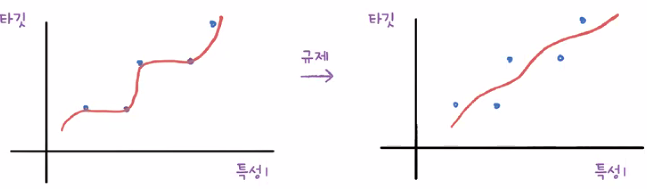

- 규제 적용 순서
    1. 특성 공학: PolynomialFeatures로 특성을 늘린다.
    2. 표준화: StandardScaler로 모든 특성의 스케일을 맞춘다.
    3. 규제 적용: 표준화된 데이터(train_scaled)를 사용해 릿지(Ridge) 또는 라쏘(Lasso) 모델을 훈련한다.

 ---
### 표준화
- 데이터의 단위를 맞춰서 모든 특성이 비슷한 스케일(크기)을 가지도록 만드는 과정입니다.

    - 공식

        $z = \frac{x-\mu}{\sigma}$

    - 기호와 설명

        $x$ : 원래 데이터 값(특성 값)

        $\mu$ : 평균

        $\sigma$ : 표준편차

        $z$ : 변화된 값

    - 데이터를 평균 0, 표준평차 1인 형태로 변환 => 모든 특성이 같은 스케일로 조정됩니다.

In [25]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

ss.fit(train_poly)

train_scaled = ss.transform(train_poly)
test_scaled = ss.transform(test_poly)

 ---
### 선형 회귀 모델에 규제를 추가한 모델을 릿지와 라쏘라고 부릅니다.

- 릿지는 계수(가중치)를 제곱한 값을 기준으로 규제를 적용
- 라쏘는 계수(가중치)의 절대값을 기준으로 규제를 적용

왜 가중치의 크기를 규제하는가? (과적합 방지)

1. 가중치가 매우 큰 경우

- 모델이 특정 특성에 지나치게 의존하고 있음을 의미합니다. (모델의 복잡도가 높음)
- 학습 데이터의 미세한 잡음(노이즈)까지 억지로 학습하여, 새로운 데이터에서는 예측 오류가 커집니다. (과적합)

2. 가중치가 작은 경우

- 모델이 여러 특성에 걸쳐 영향력을 분산하고 있음을 의미합니다.
- 특정 특성의 이상치에 덜 민감하게 반응하며, 학습 데이터 외의 새로운 데이터에 대해서도 안정적인 예측을 수행합니다. (일반화 성능 향상)

---

규제의 원리

- 손실 함수(loss function)는 모델의 예측이 실제 값과 얼마나 다른지를 수치로 나타내는 함수이며 모델은 이 손실 함수 값을 최소화하도록 학습합니다.

- 이 손실 함수는 보통 오차 항 + 규제 항으로 구성됩니다.
    1. 오차를 줄이려면: $\hat{y}$를 $y$에 가깝게 만들어야 합니다.
    2. 규제항을 줄이려면: 가중치 $w_j$의 크기를 작게 만들어야 합니다.

---

## 리지(Ridge) 회귀

1. 손실 함수 (Loss Function)
    - 순수하게 데이터의 오차를 측정하는 부분입니다. 리지 회귀는 기본적으로 평균 제곱 오차(MSE)를 사용합니다.

    $$
    MSE = \frac{1}{n} \sum^n_{i=1}{(y_i - \hat{y}_i)^2}
    $$

    - 의미: 모델의 예측값($\hat{y}_i$)과 실제값($y_i$) 사이의 차이를 제곱하여 모두 더한 뒤, 데이터의 개수($n$)로 나누어 평균을 낸 것입니다.

    - 역할: 모델이 학습 데이터에 잘 맞도록(데이터를 잘 설명하도록) 유도합니다.
---

2. 목적 함수 (Objective Function)
    - 모델이 학습을 통해 최종적으로 최소화하려는 대상입니다. 손실 함수(MSE)에 L2 규제항을 더하여 완성됩니다.

    $$
    J(w) = \frac{1}{n} \sum_{i=1}^{n}{(y_i - \hat{y}_i)^2} + \alpha \sum^p_{j=1}{w^2_j}
    $$

    - 목적 함수는 다음 두 부분의 합으로 이루어져 있습니다.

        ① 오차항 (MSE): $\frac{1}{n} \sum^n_{i=1}{(y_i - \hat{y}_i)^2}$
        
        ② 규제항 (L2 Penalty): $\alpha\sum^p_{j=1}{w^2_j}$
        
        - $\alpha$ (알파): 규제의 강도를 조절하는 하이퍼파라미터입니다.

            값이 클수록 규제가 강해지고, $\alpha=0$이면 일반 선형 회귀의 목적 함수(=단순 MSE)와 동일해집니다.

            => 알파가 커지면 가중치에 대한 벌점이 커지기 때문에, 목적 함수를 최소화하는 과정에서 모델은 가중치를 작게 유지하려는 방향으로 학습됩니다.

        - $w^2_j$: 각 특성(Feature)의 가중치(기울기)를 제곱하여 더한 값입니다.

        - $p$: 사용된 특성(feature)의 개수를 의미합니다. (참고: 절편 $b$는 규제하지 않으므로 가중치 $w$에만 적용됩니다.)

        - 역할: 가중치들의 값을 작게 만들어 모델의 복잡도를 낮춥니다. 이를 통해 과적합(Overfitting)을 방지합니다.

 ---
3. 특징

리지 회귀는 예측 오차를 줄이려는 노력과 가중치를 작게 유지하려는 노력을 동시에 고려하여 더 일반화된 모델을 만듭니다.

In [26]:
from sklearn.linear_model import Ridge

ridge = Ridge()
ridge.fit(train_scaled, train_target)
print(ridge.score(train_scaled, train_target))

0.9896101671037343


In [27]:
print(ridge.score(test_scaled, test_target))

0.9790693977615387


훈련 점수가 테스트 점수보다 약간 높은 아주 전형적이고 바람직한 모습입니다.

Ridge 모델에서는 alpha 매개변수를 조정하여 성능을 더 미세하게 튜닝할 수 있습니다.

---

In [28]:
import matplotlib.pyplot as plt

train_score = []
test_score = []

### 사람이 직접 지정해야 하는 매개변수를 하이퍼파라미터 라고 합니다.

적절한 alpha 값을 찾아 봅니다.

In [29]:
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]
for alpha in alpha_list:
    ridge = Ridge(alpha=alpha)

    ridge.fit(train_scaled, train_target)

    train_score.append(ridge.score(train_scaled, train_target))
    test_score.append(ridge.score(test_scaled, test_target))

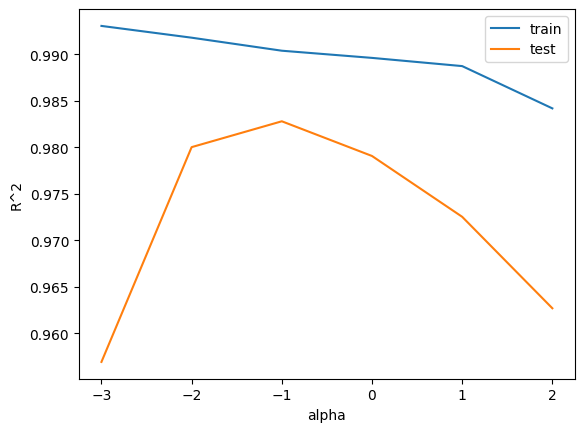

In [31]:
plt.plot(np.log10(alpha_list), train_score, label='train')
plt.plot(np.log10(alpha_list), test_score, label='test')
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.legend()
plt.show()

- 알파값이 -3인 경우에는 훈련 세트에는 잘 맞고 테스트세트에는 형편없는 과대 적합 모습이 보입니다.

- 앞아값이 2인 경우에는 훈련 세트와 테스트 세트 점수가 모두 낮아지는 과소 적합이 보입니다.

**적절한 alpha 값은 두 그래프가 가장 가깝고 테스트 세트의 점수가 가장 높은 -1, 즉 10의 마이너스 1승인 0.1입니다.**

In [32]:
ridge = Ridge(alpha=0.1)
ridge.fit(train_scaled, train_target)

print(ridge.score(train_scaled, train_target))
print(ridge.score(test_scaled, test_target))

0.9903815817570367
0.9827976465386928


 ---

## 2. 라쏘 회귀 (Lasso Regression)

- **정의**: 모델의 손실 함수에 가중치의 절댓값 합인 L1 규제(L1 Penalty)를 추가한 회귀 모델입니다.
- **핵심**: 가중치($w$)를 완전히 0으로 만들 수 있어, 자동으로 특성 선택(Feature Selection)을 수행하는 것이 큰 특징입니다.

---

### (1) 목적 함수 (Objective Function)

모델이 학습을 통해 최종적으로 최소화하려는 대상입니다. 손실 함수(MSE)에 L1 규제항을 더하여 완성됩니다.

$$
J(w) = \frac{1}{n}\sum^n_{i=1}{(y_i-\hat{y}_i)^2}+\alpha\sum^p_{j=1}{|w_j|}
$$

- **목적 함수는 다음 두 부분의 합으로 이루어져 있습니다.**
    - **① 오차항 (MSE)**: $\frac{1}{n}\sum^n_{1=1}{(y_i-\hat{y}_i)^2}$
    - **② 규제항 (L1 Penalty)**: \alpha\sum^p_{j=1}{|w_j|}

---

### (2) 주요 구성 요소 설명

- $\alpha$ **(알파)**: 규제의 강도를 조절하는 하이퍼파라미터입니다.

    - $\alpha$가 커질수록 가중치에 가해지는 벌점이 커져 가중치가 **0**이 될 확률이 높아집니다.
    - $\alpha=0$이면 일반 선형 회귀와 동일한 목적 함수를 가집니다.

- $|w_j|$: 각 특성(Feature) 가중치의 **절댓값**을 합산한 것입니다. (제곱을 사용하는 릿지와 다른 점입니다.)

- $p$: 모델에 사용된 특성의 개수입니다. (참고: 절편 $b$는 규제하지 않고 가중치 $w$에만 적용됩니다.)

- 가중치가 0이 되는 경우 (오차를 줄이는 힘이 $\alpha$보다 약한 특성은 버린다)

    - 라쏘에서는 각 특성이 현재 예측 오차(잔차)를 얼마나 줄일 수 있는지로 평가되며 이 기여도가 규제 강도($\alpha$)보다 작으면 해당 특성은 중요하지 않다고 판단되어 가중치가 0으로 설정됩니다.

---

### (3) 라쏘 회귀의 주요 특징

- **희소성 (Sparsity)**: 중요도가 낮은 변수의 가중치를 0으로 만들어 모델을 매우 단순하게 만듭니다.
- **특성 선택**: 수많은 변수 중 의미 있는 변수가 무엇인지 골라내는 필터 역할을 합니다.
- **해석력**: 0이 되지 않고 살아남은 변수들만 분석하면 되므로 결과 해석이 직관적입니다.
- 최적화 반복 횟수 (max_iter): 모델이 최적의 가중치를 찾기 위해 계산을 반복하는 최대 횟수이며, 라쏘는 규제가 강할수록 수렴(최적의 값 도달)이 어려울 수 있어 충분한 반복 횟수를 설정하는 것이 중요합니다.

---

### (4) 릿지(Ridge) vs 라쏘(Lasso) 요약

| **구분** | **릿지 회귀 (Ridge)** | **라쏘 회귀 (Lasso)** |
| :--- | :--- | :--- |
| **규제 방식** | L2 규제 | L1 규제 |
| **가중치 결과** | 0에 가깝게 축소 (정확히 0은 되지 않음) | **일부 가중치가 정확히 0이 될 수 있음** |
| **주요 목적** | 모델 안정성, 과적합 방지 | **특성 선택**, 모델 단순화 |

In [34]:
from sklearn.linear_model import Lasso

lasso = Lasso()
lasso.fit(train_scaled, train_target)
print(lasso.score(train_scaled, train_target))

0.989789897208096


In [35]:
print(lasso.score(test_scaled, test_target))

0.9800593698421884


In [36]:
train_score = []
test_score = []

alpha_list = [0.1, 1, 10, 100]
for alpha in alpha_list:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(train_scaled, train_target)
    train_score.append(lasso.score(train_scaled, train_target))
    test_score.append(lasso.score(test_scaled, test_target))

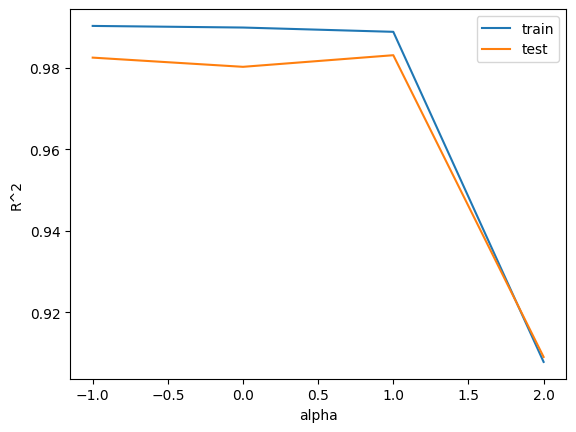

In [37]:
plt.plot(np.log10(alpha_list), train_score, label='train')
plt.plot(np.log10(alpha_list), test_score, label='test')
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.legend()
plt.show()

### 그래프에서 최적의 알파값은 1 입니다. 로그가 적용 되기 전의 값은 $10^1 = 10$ 입니다.

In [58]:
lasso = Lasso(alpha=10)
lasso.fit(train_scaled, train_target)
print(lasso.score(train_scaled, train_target))
print(lasso.score(test_scaled, test_target))

0.9888067471131866
0.9824470598706695


In [59]:
print(lasso.coef_)

[ 0.          0.          0.         12.14852453 55.44856399 42.23100799
  0.          0.         13.70596191  0.         43.2185952   5.7033775
 47.46254536  7.42309425 11.85823365  0.          0.         13.53038193
 21.22111356  0.          0.          0.          0.          0.
  0.         18.66993032  0.          0.          0.         15.81041778
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.         18.14672268  0.          0.          0.
  0.         15.51272953  0.          0.          0.          0.
  0.        ]


In [65]:
print(len(lasso.coef_[lasso.coef_ == 0]))

40
